# 04 Neurosymbolic Inference Heatmap

- The frozen detector still provides the backbone, RPN, proposals, RoI pooling, and neural bbox regression.
- The symbolic classifier replaces only the RoI classification branch.
- Explanations come from the sparse oblique tree path weights reshaped back into the pooled RoI lattice, not from Grad-CAM.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from neuro.datasets import DeepPCBDataset
from neuro.inference import visualize_prediction
from neuro.transforms import build_eval_transforms
from neuro.config import load_yaml
from util.artifacts import latest_run_checkpoint
from neurosym.inference import (
    aggregate_detection_heatmaps,
    explain_hybrid_detections,
    load_neurosymbolic_detector,
    run_neurosymbolic_inference,
    select_detection_indices,
    subset_detection,
)

PROJECT_ROOT = Path.cwd().resolve()


In [2]:
model_config = load_yaml(PROJECT_ROOT / "configs/model.yaml")
train_config = load_yaml(PROJECT_ROOT / "configs/train_deeppcb.yaml")

dataset_root = PROJECT_ROOT / train_config["dataset"]["root"]
checkpoint_path = latest_run_checkpoint(PROJECT_ROOT / train_config["artifacts"]["checkpoint_dir"])
symbolic_checkpoint_path = PROJECT_ROOT / "checkpoints" / "symbolic" / "sodt_run1.pt"
selection_lane = "paper_faithful"

hybrid_model, detector_checkpoint = load_neurosymbolic_detector(
    checkpoint_path,
    PROJECT_ROOT / "configs/model.yaml",
    symbolic_checkpoint_path,
    device=train_config.get("device"),
    selection_lane=selection_lane,
)

test_dataset = DeepPCBDataset(
    dataset_root=dataset_root,
    split_file=train_config["dataset"]["test_split"],
    transforms=build_eval_transforms(),
    class_names=tuple(model_config["model"]["class_names"]),
)

checkpoint_path, symbolic_checkpoint_path, selection_lane


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\handi/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:11<00:00, 9.27MB/s]


(WindowsPath('C:/Users/handi/OneDrive/Documents/WiszeL/UNS/Semester 8/pcb_skripsi/checkpoints/run3.pt'),
 WindowsPath('C:/Users/handi/OneDrive/Documents/WiszeL/UNS/Semester 8/pcb_skripsi/checkpoints/symbolic/sodt_run1.pt'),
 'paper_faithful')

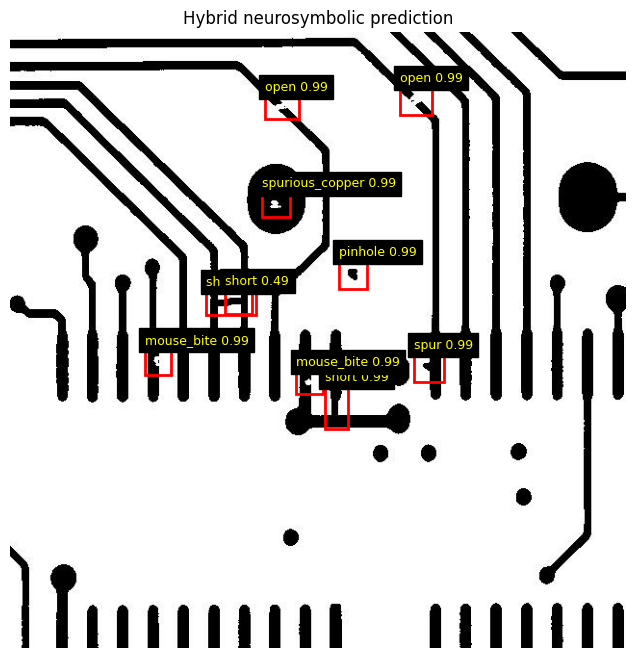

(tensor([1, 1, 2, 2, 3, 3, 4, 5, 6, 2]),
 tensor([0.9896, 0.9896, 0.9896, 0.9896, 0.9896, 0.9896, 0.9896, 0.9896, 0.9896,
         0.4894]))

In [3]:
sample_index = 0
image, target = test_dataset[sample_index]
detection = run_neurosymbolic_inference(hybrid_model, [image])[0]

fig, ax = plt.subplots(figsize=(8, 8))
visualize_prediction(
    image,
    detection,
    tuple(model_config["model"]["class_names"]),
    score_threshold=0.3,
    ax=ax,
)
ax.set_title("Hybrid neurosymbolic prediction")
plt.show()

detection["labels"][:10], detection["scores"][:10]


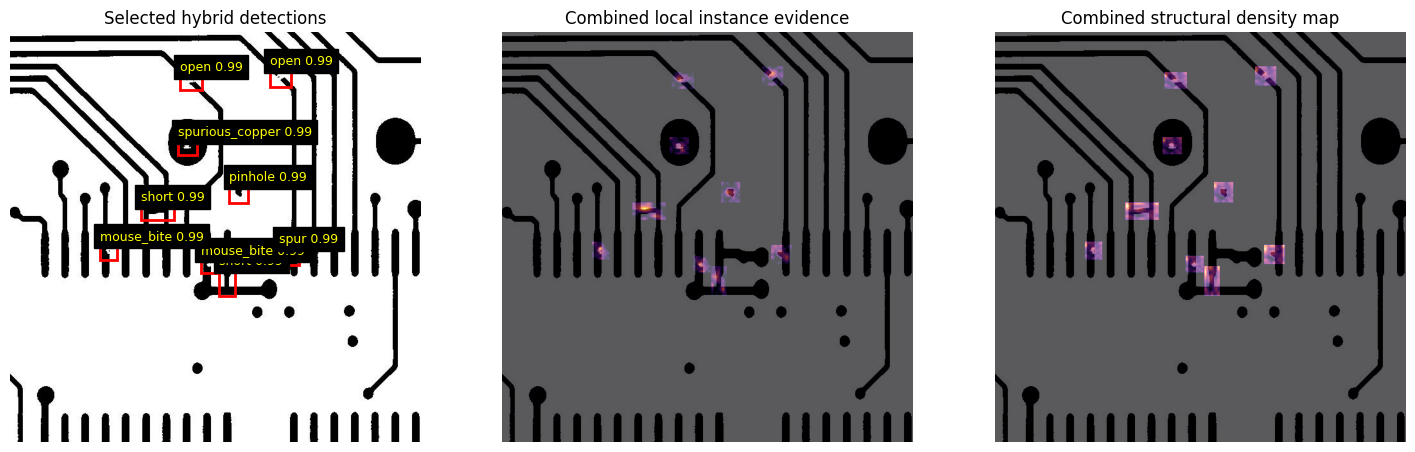

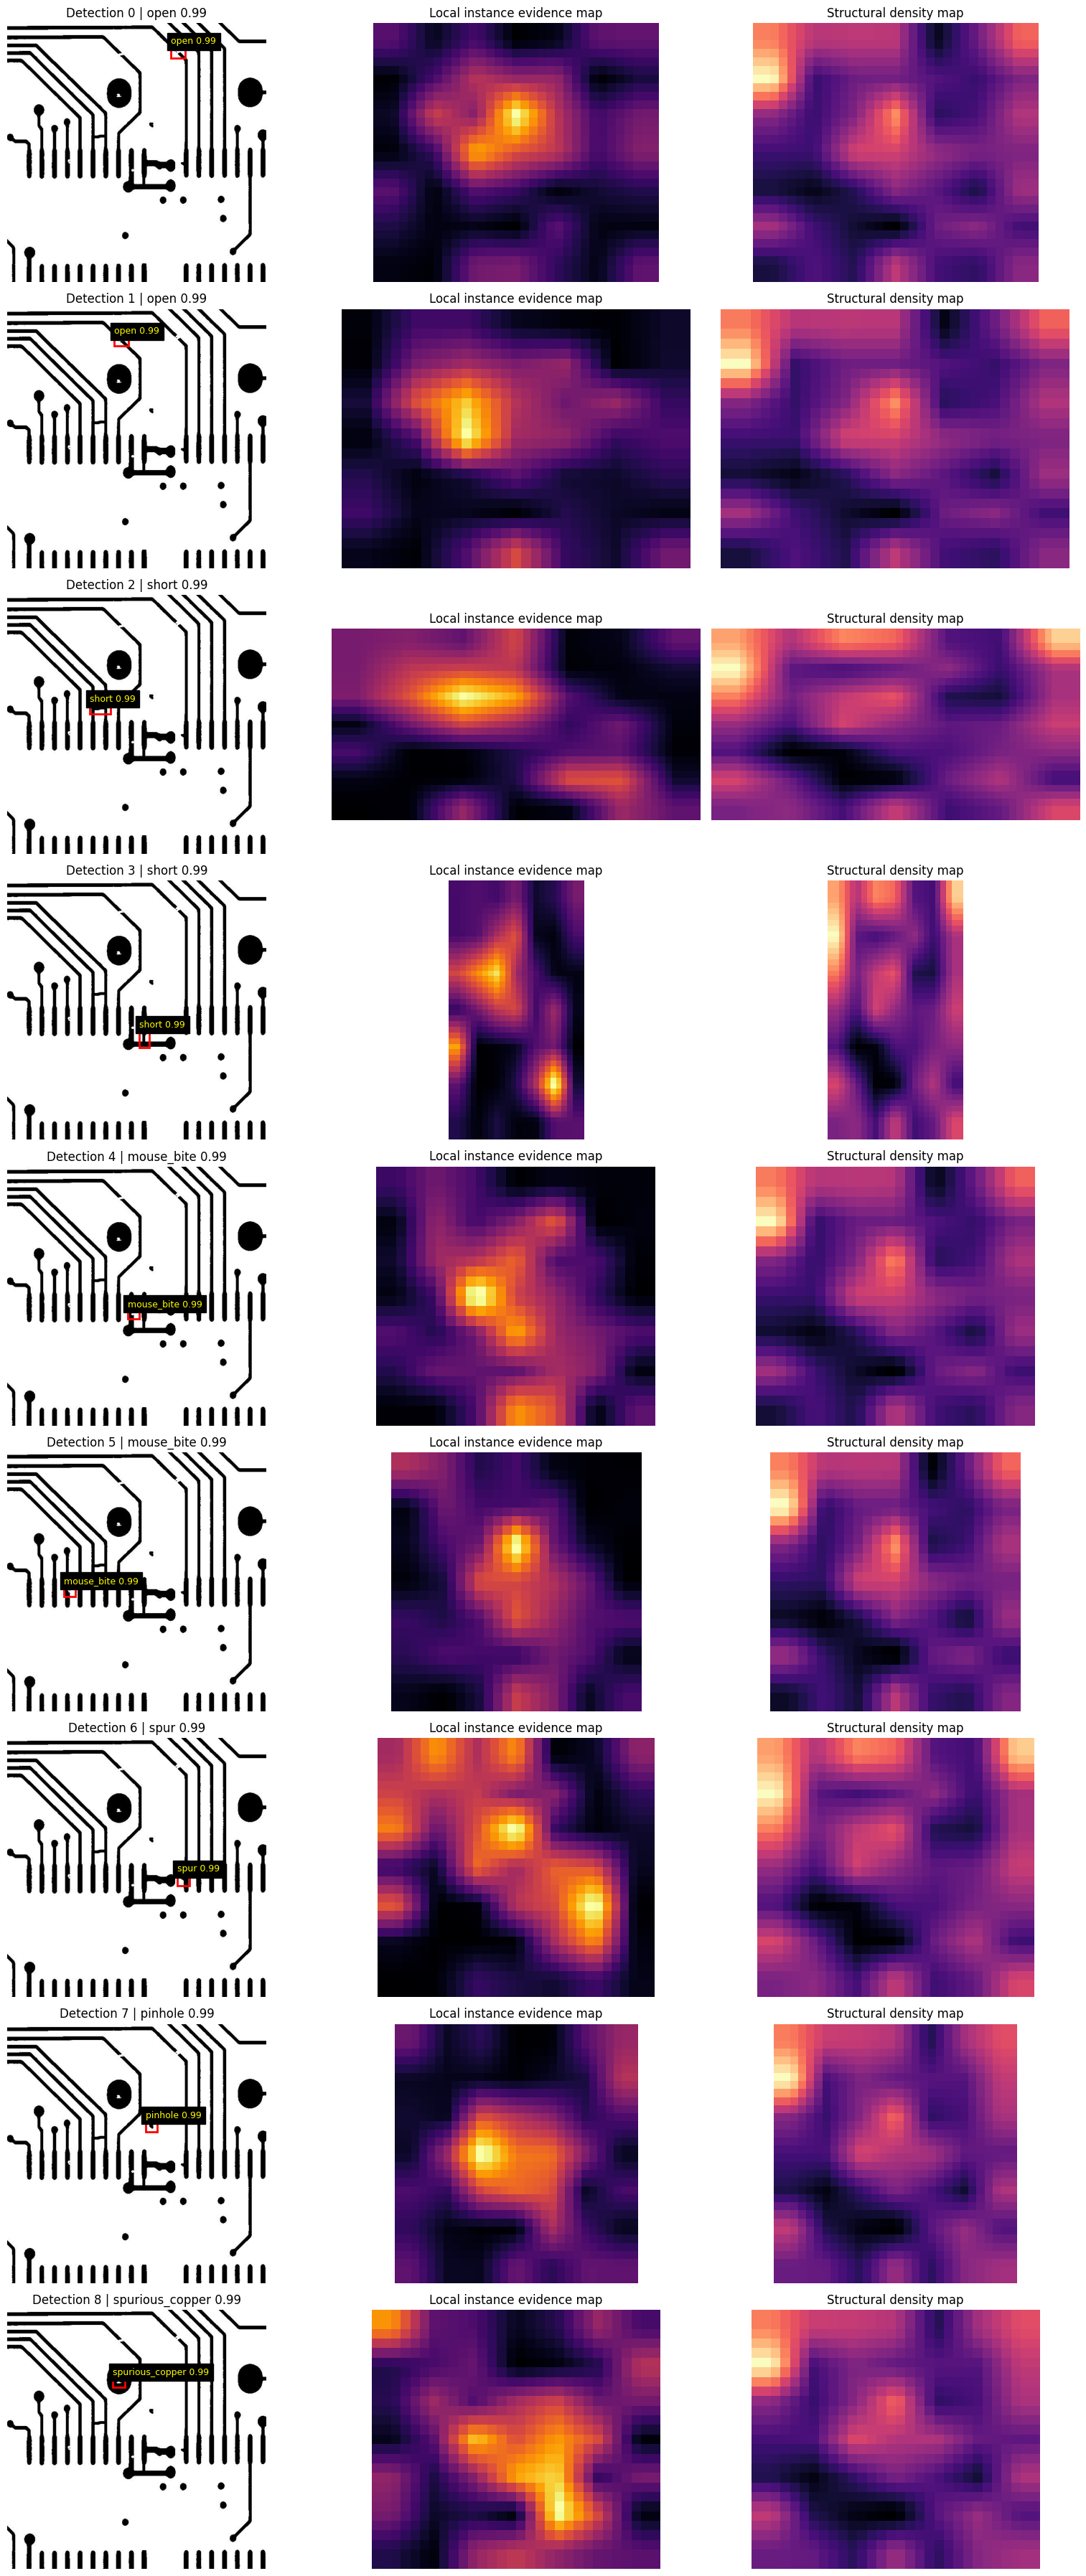

,node_index,decision,score,active_original_features,top_structural_channels,top_positive_local_channels,top_positive_local_coords
0,0,left,10.217777,305,"[228, 6, 44]","[192, 220, 186]","[(6, 3), (6, 2), (1, 4)]"
1,1,right,-7.781185,61,"[192, 247, 106]","[192, 44]","[(3, 2), (1, 2), (2, 3)]"
2,4,right,-7.217027,47,"[25, 116, 186]","[116, 186, 193]","[(2, 3), (3, 3), (3, 6)]"


,original_feature_index,signed_contribution,absolute_contribution,retained_feature_index,channel,row,col
0,9426,1.399542,1.399542,9426,192,2,4
1,9425,1.104827,1.104827,9425,192,2,3
2,9417,1.098337,1.098337,9417,192,1,2
3,9431,1.078125,1.078125,9431,192,3,2
4,9141,1.058228,1.058228,9141,186,3,6
5,9423,0.998420,0.998420,9423,192,2,1
6,5701,0.989946,0.989946,5701,116,2,3
7,9433,0.940238,0.940238,9433,192,3,4
8,9134,0.930115,0.930115,9134,186,2,6
9,10825,0.910252,0.910252,10825,220,6,3


,original_feature_index,signed_contribution,absolute_contribution,retained_feature_index,channel,row,col
0,12374,-1.186413,1.186413,12374,252,3,5
1,10616,-0.408591,0.408591,10616,216,4,4
2,10617,-0.341482,0.341482,10617,216,4,5
3,6249,-0.197161,0.197161,6249,127,3,5
4,10624,-0.162250,0.162250,10624,216,5,5
5,5709,-0.159084,0.159084,5709,116,3,4
6,10976,-0.156894,0.156894,10976,224,0,0
7,10983,-0.154349,0.154349,10983,224,1,0
8,5686,-0.126321,0.126321,5686,116,0,2
9,6503,-0.109524,0.109524,6503,132,5,0


,channel,score
0,192,11.086754
1,186,4.948075
2,116,4.077153
3,220,2.164026
4,198,1.200969
5,69,1.156874
6,44,0.985612
7,216,0.974838


,channel,score
0,228,6.912440
1,192,4.244727
2,6,2.520478
3,44,2.445625
4,25,2.344848
5,216,2.313168
6,224,2.277291
7,178,1.704507


,row,col,signed_contribution,absolute_contribution
0,2,3,2.984298,2.984298
1,3,2,2.443953,2.443953
2,3,3,1.735588,1.735588
3,2,1,1.609022,1.609022
4,3,4,1.480827,1.480827
5,2,4,1.438533,1.438533
6,1,2,1.426778,1.426778
7,1,4,1.182663,1.182663
8,1,3,1.159029,1.159029
9,3,6,1.058228,1.058228


,row,col,signed_contribution,absolute_contribution
0,1,0,2.554159,2.554159
1,2,3,2.019693,2.019693
2,0,0,1.903931,1.903931
3,0,6,1.773233,1.773233
4,3,2,1.566730,1.566730
5,3,3,1.519008,1.519008
6,6,3,1.421416,1.421416
7,0,2,1.410612,1.410612
8,0,3,1.393628,1.393628
9,0,1,1.378051,1.378051


In [4]:
score_threshold = 0.3
max_explanations = 9
explanation_mode = "local_instance_evidence_map"
structural_mode = "global_or_structural_density_map"

selected_indices = select_detection_indices(
    detection,
    score_threshold=score_threshold,
    max_detections=max_explanations,
)

if selected_indices:
    selected_detection = subset_detection(detection, selected_indices)
    explanations = explain_hybrid_detections(
        hybrid_model,
        detection,
        image_shape=tuple(image.shape[-2:]),
        detection_indices=selected_indices,
        mode=explanation_mode,
    )
    structural_explanations = explain_hybrid_detections(
        hybrid_model,
        detection,
        image_shape=tuple(image.shape[-2:]),
        detection_indices=selected_indices,
        mode=structural_mode,
    )
    combined_heatmap = aggregate_detection_heatmaps(
        explanations,
        reduction="max",
        score_weighted=True,
        normalize=True,
    )
    combined_structural_heatmap = aggregate_detection_heatmaps(
        structural_explanations,
        reduction="max",
        score_weighted=True,
        normalize=True,
    )

    image_array = image.detach().cpu().permute(1, 2, 0).clamp(0.0, 1.0).numpy()
    class_names = tuple(model_config["model"]["class_names"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    visualize_prediction(
        image,
        selected_detection,
        class_names,
        score_threshold=0.0,
        ax=axes[0],
    )
    axes[0].set_title("Selected hybrid detections")
    axes[1].imshow(image_array, cmap="gray" if image_array.shape[-1] == 1 else None)
    axes[1].imshow(combined_heatmap, cmap="inferno", alpha=0.65)
    axes[1].set_title("Combined local instance evidence")
    axes[1].axis("off")
    axes[2].imshow(image_array, cmap="gray" if image_array.shape[-1] == 1 else None)
    axes[2].imshow(combined_structural_heatmap, cmap="magma", alpha=0.65)
    axes[2].set_title("Combined structural density map")
    axes[2].axis("off")
    plt.show()

    fig, axes = plt.subplots(len(explanations), 3, figsize=(16, 4 * len(explanations)))
    if len(explanations) == 1:
        axes = [axes]

    for row, (explanation, structural_explanation) in enumerate(zip(explanations, structural_explanations)):
        explained_detection = subset_detection(detection, [explanation["detection_index"]])
        visualize_prediction(
            image,
            explained_detection,
            class_names,
            score_threshold=0.0,
            ax=axes[row][0],
        )
        label_name = class_names[explanation["label"] - 1]
        axes[row][0].set_title(
            f"Detection {explanation['detection_index']} | {label_name} {explanation['score']:.2f}"
        )
        axes[row][1].imshow(explanation["detection_box_heatmap"], cmap="inferno")
        axes[row][1].set_title("Local instance evidence map")
        axes[row][1].axis("off")
        axes[row][2].imshow(structural_explanation["detection_box_heatmap"], cmap="magma")
        axes[row][2].set_title("Structural density map")
        axes[row][2].axis("off")

    plt.tight_layout()
    plt.show()

    focus_explanation = explanations[0]
    focus_structural_explanation = structural_explanations[0]
    focus_label = class_names[focus_explanation["label"] - 1]

    node_summary_table = pd.DataFrame(
        [
            {
                "node_index": node["node_index"],
                "decision": "left" if node.get("went_left", False) else "right",
                "score": node.get("score"),
                "active_original_features": node["active_original_feature_count"],
                "top_structural_channels": [entry["channel"] for entry in node["top_structural_channels"][:3]],
                "top_positive_local_channels": [entry["channel"] for entry in node.get("top_positive_local_channels", [])[:3]],
                "top_positive_local_coords": [
                    (entry["row"], entry["col"])
                    for entry in node.get("top_positive_local_coordinates", [])[:3]
                ],
            }
            for node in focus_explanation["node_summaries"]
        ]
    )

    top_positive_feature_table = pd.DataFrame(focus_explanation["top_positive_contributing_features"][:10])
    top_negative_feature_table = pd.DataFrame(focus_explanation["top_negative_contributing_features"][:10])
    top_local_cell_table = pd.DataFrame(focus_explanation["top_positive_local_cells"][:10])
    top_structural_cell_table = pd.DataFrame(focus_structural_explanation["top_structural_cells"][:10])
    top_local_channel_table = pd.DataFrame(focus_explanation["top_positive_local_channels"][:8])
    top_structural_channel_table = pd.DataFrame(focus_structural_explanation["top_structural_channels"][:8])

    display(node_summary_table)
    display(top_positive_feature_table)
    display(top_negative_feature_table)
    display(top_local_channel_table)
    display(top_structural_channel_table)
    display(top_local_cell_table)
    display(top_structural_cell_table)

    {
        "focus_detection": {
            "detection_index": focus_explanation["detection_index"],
            "label": focus_label,
            "score": focus_explanation["score"],
            "leaf_index": focus_explanation["leaf_index"],
            "symbolic_label_confidence": focus_explanation["symbolic_label_confidence"],
        },
        "intrinsic_reasoning_summary": focus_explanation["intrinsic_reasoning_summary"],
        "map_types": focus_explanation["reasoning_summary"]["map_types"],
    }
else:
    print("No detections above the current score threshold.")
